In this project, we used ChipWhisperer to execute code and collect power traces. Given a C file containing an ID validation function ('a' or 'v_func') and a function computing the last digit of an ID ('b' or 'f_func')— where hardware triggers determine the trace capture time — the project consists of two parts:

- Understanding the system: Capturing baseline traces, determining optimal trace length, and aligning the execution windows.

- DPA attack: We collected traces of the verification function using random valid IDs. Then, treating the target ID as unknown, we successfully recovered it using a Differential Power Analysis (DPA) attack based only on the collected traces.

In [147]:
# import relevant libraries
import chipwhisperer as cw
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import trange

# initiate scope and target definitions for chipwhisperer
scope = cw.scope()
target = cw.target(scope, cw.targets.SimpleSerial)
scope.default_setup()
SAMPLES = 1000
scope.adc.samples = SAMPLES  # scope.adc - The Analog to Digital converter on the chipwhisperer
                         # samples = 1000 - The number of ADC samples to record in a single capture

scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 1410973                   to 12958213                 
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.adc_freq                     changed from 29538459                  to 29538471                 
scope.clock.adc_rate                     changed from 29538459.0                to 29538471.0               
scope.clock.clkgen_

creating a HEX file

In [133]:
%%sh
make PLATFORM=CWLITEARM SOURCE=chipwhisperer_hw2_dpa.c

No CRYPTO_TARGET passed - defaulting to TINYAES128C
Building for platform CWLITEARM with CRYPTO_TARGET=TINYAES128C
SS_VER set to SS_VER_1_1
SS_VER set to SS_VER_1_1
Blank crypto options, building for AES128
.
Welcome to another exciting ChipWhisperer target build!!
arm-none-eabi-gcc.exe (Arm GNU Toolchain 14.2.Rel1 (Build arm-14.52)) 14.2.1 20241119
Copyright (C) 2024 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

mkdir objdir-CWLITEARM 
.
Compiling:
    chipwhisperer_hw2_dpa.c ...Done!
.
Compiling:
    C:/Users/tamar/ChipWhisperer/chipwhisperer/firmware/mcu/simpleserial/simpleserial.c ...Done!
.
Compiling:
    C:/Users/tamar/ChipWhisperer/chipwhisperer/firmware/mcu/hal/hal.c ...Done!
.
Compiling:
    C:/Users/tamar/ChipWhisperer/chipwhisperer/firmware/mcu/hal//stm32f3/stm32f3_hal.c ...Done!
.
Compiling:
    C:/Users/tamar/ChipWhisperer/chipwhisperer/f

C:/Program Files (x86)/Arm GNU Toolchain arm-none-eabi/14.2 rel1/bin/../lib/gcc/arm-none-eabi/14.2.1/../../../../arm-none-eabi/bin/ld.exe: C:/Program Files (x86)/Arm GNU Toolchain arm-none-eabi/14.2 rel1/bin/../lib/gcc/arm-none-eabi/14.2.1/thumb/v7e-m/nofp\libg_nano.a(libc_a-closer.o): in function `_close_r':
closer.c:(.text._close_r+0xc): warning: _close is not implemented and will always fail


C:/Program Files (x86)/Arm GNU Toolchain arm-none-eabi/14.2 rel1/bin/../lib/gcc/arm-none-eabi/14.2.1/../../../../arm-none-eabi/bin/ld.exe: C:/Program Files (x86)/Arm GNU Toolchain arm-none-eabi/14.2 rel1/bin/../lib/gcc/arm-none-eabi/14.2.1/thumb/v7e-m/nofp\libg_nano.a(libc_a-closer.o): note: the message above does not take linker garbage collection into account


C:/Program Files (x86)/Arm GNU Toolchain arm-none-eabi/14.2 rel1/bin/../lib/gcc/arm-none-eabi/14.2.1/../../../../arm-none-eabi/bin/ld.exe: C:/Program Files (x86)/Arm GNU Toolchain arm-none-eabi/14.2 rel1/bin/../lib/gcc/arm-none-eabi/14.2.1/thumb/v7e-m/nofp\libg_nano.a(libc_a-lseekr.o): in function `_lseek_r':
lseekr.c:(.text._lseek_r+0x10): warning: _lseek is not implemented and will always fail


C:/Program Files (x86)/Arm GNU Toolchain arm-none-eabi/14.2 rel1/bin/../lib/gcc/arm-none-eabi/14.2.1/../../../../arm-none-eabi/bin/ld.exe: C:/Program Files (x86)/Arm GNU Toolchain arm-none-eabi/14.2 rel1/bin/../lib/gcc/arm-none-eabi/14.2.1/thumb/v7e-m/nofp\libg_nano.a(libc_a-lseekr.o): note: the message above does not take linker garbage collection into account
C:/Program Files (x86)/Arm GNU Toolchain arm-none-eabi/14.2 rel1/bin/../lib/gcc/arm-none-eabi/14.2.1/../../../../arm-none-eabi/bin/ld.exe: C:/Program Files (x86)/Arm GNU Toolchain arm-none-eabi/14.2 rel1/bin/../lib/gcc/arm-none-eabi/14.2.1/thumb/v7e-m/nofp\libg_nano.a(libc_a-readr.o): note: the message above does not take linker garbage collection into account


C:/Program Files (x86)/Arm GNU Toolchain arm-none-eabi/14.2 rel1/bin/../lib/gcc/arm-none-eabi/14.2.1/../../../../arm-none-eabi/bin/ld.exe: C:/Program Files (x86)/Arm GNU Toolchain arm-none-eabi/14.2 rel1/bin/../lib/gcc/arm-none-eabi/14.2.1/thumb/v7e-m/nofp\libg_nano.a(libc_a-readr.o): in function `_read_r':
readr.c:(.text._read_r+0x10): warning: _read is not implemented and will always fail
C:/Program Files (x86)/Arm GNU Toolchain arm-none-eabi/14.2 rel1/bin/../lib/gcc/arm-none-eabi/14.2.1/../../../../arm-none-eabi/bin/ld.exe: C:/Program Files (x86)/Arm GNU Toolchain arm-none-eabi/14.2 rel1/bin/../lib/gcc/arm-none-eabi/14.2.1/thumb/v7e-m/nofp\libg_nano.a(libc_a-writer.o): in function `_write_r':
writer.c:(.text._write_r+0x10): warning: _write is not implemented and will always fail


C:/Program Files (x86)/Arm GNU Toolchain arm-none-eabi/14.2 rel1/bin/../lib/gcc/arm-none-eabi/14.2.1/../../../../arm-none-eabi/bin/ld.exe: C:/Program Files (x86)/Arm GNU Toolchain arm-none-eabi/14.2 rel1/bin/../lib/gcc/arm-none-eabi/14.2.1/thumb/v7e-m/nofp\libg_nano.a(libc_a-writer.o): note: the message above does not take linker garbage collection into account


C:/Program Files (x86)/Arm GNU Toolchain arm-none-eabi/14.2 rel1/bin/../lib/gcc/arm-none-eabi/14.2.1/../../../../arm-none-eabi/bin/ld.exe: warning: output-CWLITEARM.elf has a LOAD segment with RWX permissions


Done!
.
Creating load file for Flash: output-CWLITEARM.hex
arm-none-eabi-objcopy -O ihex -R .eeprom -R .fuse -R .lock -R .signature output-CWLITEARM.elf output-CWLITEARM.hex
.
Creating load file for Flash: output-CWLITEARM.bin
arm-none-eabi-objcopy -O binary -R .eeprom -R .fuse -R .lock -R .signature output-CWLITEARM.elf output-CWLITEARM.bin
.
Creating load file for EEPROM: output-CWLITEARM.eep
arm-none-eabi-objcopy -j .eeprom --set-section-flags=.eeprom="alloc,load" \
--change-section-lma .eeprom=0 --no-change-warnings -O ihex output-CWLITEARM.elf output-CWLITEARM.eep || exit 0
.
Creating Extended Listing: output-CWLITEARM.lss
arm-none-eabi-objdump -h -S -z output-CWLITEARM.elf > output-CWLITEARM.lss
.
Creating Symbol Table: output-CWLITEARM.sym
arm-none-eabi-nm -n output-CWLITEARM.elf > output-CWLITEARM.sym
Size after:
   text	   data	    bss	    dec	    hex	filename
   4948	      8	   1432	   6388	   18f4	output-CWLITEARM.elf
+--------------------------------------------------------

In [148]:
# loading the HEX file to the chipwhisperer
hex = './output-CWLITEARM.hex'
cw.program_target(scope, cw.programmers.STM32FProgrammer, hex)

Detected known STMF32: STM32F302xB(C)/303xB(C)
Extended erase (0x44), this can take ten seconds or more
Attempting to program 4955 bytes at 0x8000000
STM32F Programming flash...
STM32F Reading flash...
Verified flash OK, 4955 bytes


In [149]:
def execute_trace(command, input):
    """
    Executes a trace using the given command and input string, with the provided scope and target objects.

    Parameters:
        command (str): The command to send to the target.
        input (str): The input data to send to the target.
        scope: The scope object for controlling the capture process.
        target: The target object for sending and receiving data.

    Returns:
        tuple: A tuple containing the capture trace and the response from the target.
    """
    try:
        # Flush target and arm the scope
        target.flush()
        scope.arm()

        # Convert input to bytearray
        input_data = bytearray(input, 'utf-8')

        # Send command and data to target
        target.simpleserial_write(command, input_data)

        # Capture the trace
        ret = scope.capture()
        if ret:
            print("ERROR: Capture failed.")
            return None, None

        # Retrieve the trace and the target response
        trace = scope.get_last_trace()
        response = target.simpleserial_read('r', 1).decode('utf-8')

        return trace, response
    except Exception as e:
        print(f"An error occurred: {e}")
        return None, None

#### Trigger Count Analysis
 Measure the number of trigger counts between the trigger high and trigger low states.
 You may find the function scope.adc.trig_count useful

In [ ]:
# Those IDs are not the original IDs used while running the code
OFEK_ID = "999247315"
TAMAR_ID = "999302862"

In [136]:
traces, res = execute_trace("b", OFEK_ID)
trigger_count = scope.adc.trig_count
print("trigger_count =", trigger_count)
print("number of samples =", traces.size)
print("check digit =", res)

trigger_count = 676
number of samples = 1000
check digit = 5


In [40]:
traces, res = execute_trace("a", OFEK_ID + res)
trigger_count = scope.adc.trig_count
print("trigger_count =", trigger_count)
print("number of samples =", traces.size)
print("check result =", res)

trigger_count = 744
number of samples = 1000
check result = Y


In [155]:
traces, res = execute_trace("b", TAMAR_ID)
trigger_count = scope.adc.trig_count
print("trigger_count =", trigger_count)
print("number of samples =", traces.size)
print("check digit =", res)

trigger_count = 660
number of samples = 1000
check digit = 2


In [156]:
traces, res = execute_trace("a", TAMAR_ID + res)
trigger_count = scope.adc.trig_count
print("trigger_count =", trigger_count)
print("number of samples =", traces.size)
print("check result =", res)


trigger_count = 728
number of samples = 1000
check result = Y


we choose to take 1000 samples (for the samples of both functions in their whole triggered section).
we can see that the number of samples and the result of both functions was correct

 #### Noise Reduction and Visualization

1. Collect 100 traces for each partner’s ID (if working alone, use the constant 0 ID along
 with your ID).

In [151]:
Ofek_traces_b = []
Ofek_traces_a = []

for i in range (100):
    traces, res = execute_trace("b", OFEK_ID)
    Ofek_traces_b.append(traces)

for i in range (100):
    traces, res = execute_trace("a", OFEK_ID + res)
    Ofek_traces_a.append(traces)


Tamar_traces_b = []
Tamar_traces_a = []

for i in range (100):
    traces, res = execute_trace("b", TAMAR_ID)
    Tamar_traces_b.append(traces)

for i in range (100):
    traces, res = execute_trace("a", TAMAR_ID + res)
    Tamar_traces_a.append(traces)
    

 2. Compute the trace-wise average of these traces to obtain a noise-reduced trace.

We did 100 traces for each function and each ID and compute the trace wise average

In [152]:
Ofek_traces_b = np.array(Ofek_traces_b)
Ofek_traces_b_mean = np.mean(Ofek_traces_b, axis = 0)

Ofek_traces_a = np.array(Ofek_traces_a)
Ofek_traces_a_mean = np.mean(Ofek_traces_a, axis = 0)

Tamar_traces_b = np.array(Tamar_traces_b)
Tamar_traces_b_mean = np.mean(Tamar_traces_b, axis = 0)

Tamar_traces_a = np.array(Tamar_traces_a)
Tamar_traces_a_mean = np.mean(Tamar_traces_a, axis = 0)

 3. Generate and include the following graphs:

 • A plot of the noise-reduced traces for both IDs.
 

In the next plots we can see the cyclicality that became from the loop in the function.

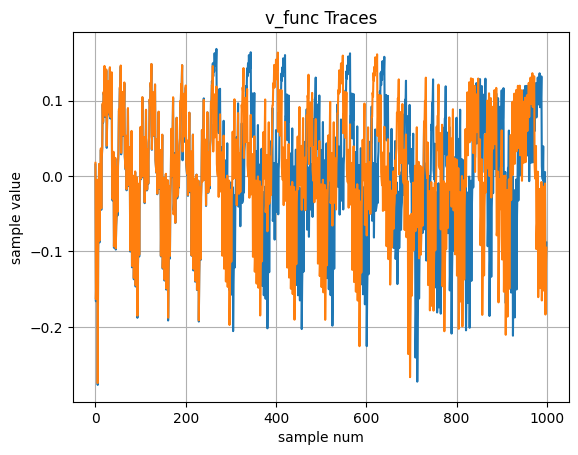

In [153]:
plt.plot()
plt.plot(Ofek_traces_a_mean)
plt.plot(Tamar_traces_a_mean)
plt.xlabel("sample num")
plt.ylabel("sample value")
plt.title("v_func Traces")
plt.grid()
plt.show()



 • A plot of the differences between the traces.

We can see that at the begining there is almost no differences between the plots and that the differences start just after the first change in the IDs (the 3rd digit, around sample 200) and then continues because it affect the whole code after that.

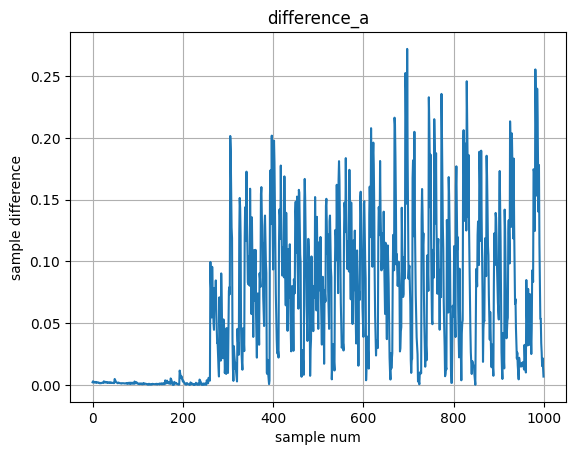

In [154]:
difference_b = abs(Ofek_traces_b_mean - Tamar_traces_b_mean)
difference_a = abs(Ofek_traces_a_mean - Tamar_traces_a_mean)

plt.plot(range(SAMPLES), difference_a)
plt.xlabel("sample num")
plt.ylabel("sample difference")
plt.title("difference_a")
plt.grid()
plt.show()

When we changed a single digit in the ID, we saw differences across the entire trace — even after the relevant computation had finished.
We realized this happens because the change affects variables used in the next loop iterations.
To isolate the effect, we added the same digit with the same weight in a different index, so the overall impact would cancel out.
This worked — the traces differed only during the relevant part, and became equal again afterward.

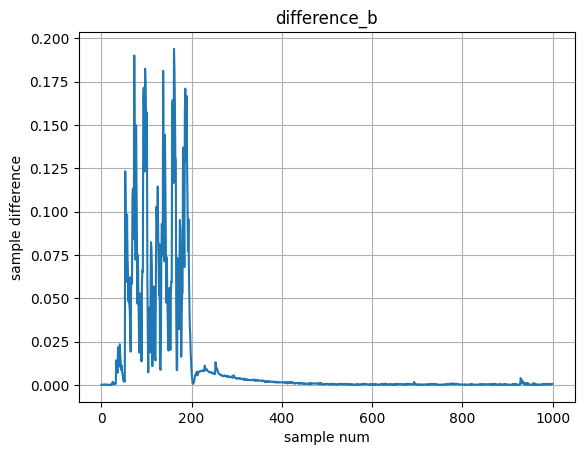

In [346]:
FIRST_ID = "00900000"
SECOND_ID = "90000000"

FIRST_ID_b = []
SECOND_ID_b = []

for i in range (100):
    traces, res = execute_trace("b", FIRST_ID)
    FIRST_ID_b.append(traces)

for i in range (100):
    traces, res = execute_trace("b", SECOND_ID)
    SECOND_ID_b.append(traces)

FIRST_ID_b = np.array(FIRST_ID_b)
FIRST_ID_b_mean = np.mean(FIRST_ID_b, axis = 0)

SECOND_ID_b = np.array(SECOND_ID_b)
SECOND_ID_b_mean = np.mean(SECOND_ID_b, axis = 0)

difference_b = abs(SECOND_ID_b_mean - FIRST_ID_b_mean)

plt.plot(range(SAMPLES), difference_b)
plt.xlabel("sample num")
plt.ylabel("sample difference")
plt.title("difference_b")
plt.grid()
plt.show()

#### Differential Power Analysis (DPA) Attack

1. Generate a random 8-digit and use it as input to f_func to create random 9-digit ID .

In [66]:
import random

In [107]:
# Generate random ID
RANDOM_ID = ''.join(str(random.randint(0, 9)) for _ in range(8))
traces, res = execute_trace("b", RANDOM_ID)
RANDOM_ID = RANDOM_ID + res
print("RANDOM_ID =", RANDOM_ID)

RANDOM_ID = 814297008


 2. Collect leakage trace for this ID over v_func.


In [109]:
Random_traces_V = []

for i in range (10):
    traces, res = execute_trace("a", RANDOM_ID)
    Random_traces_V.append(traces)

Random_traces_V = np.array(Random_traces_V)
Random_traces_V_mean = np.mean(Random_traces_V, axis = 0)

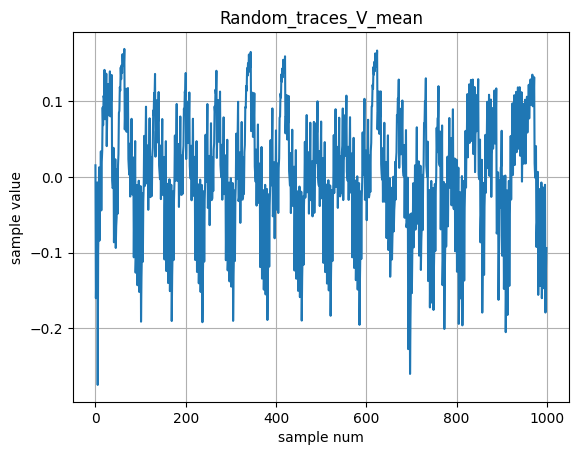

In [110]:
plt.plot(range(SAMPLES), Random_traces_V_mean)
plt.xlabel("sample num")
plt.ylabel("sample value")
plt.title("Random_traces_V_mean")
plt.grid()
plt.show()

3. Assume you have forgotten the generated ID but retained the trace.
 4. Design and implement a DPA attack to recover the unknown ID.
 5. You may take additional traces, but they must not be generated as a function of the
 unknown ID.

To recover the unknown ID using a DPA attack, we analyzed the provided trace of the secret 9-digit ID.
For each index (digit position), we simulated all 10 possible digit values (0–9), one at a time, and measured the point at which the trace began to diverge from the original trace.
We assumed that the correct digit would cause the smallest early difference, i.e., the trace would remain similar to the original for the longest duration.
After identifying the most likely digit for that index, we fixed it and repeated the process for the next digit.
This iterative approach allowed us to recover the full ID without directly querying the device using the original input.

In [ ]:
ID = ["0" for _ in range(9)]

# run over the ID indexes 
for i in range(8): 
    variance_score = [0 for _ in range(10)]
    # indexes indicate the range of calculating the i'th digit
    start = 70 * i
    end = start + 50

    # run over all digits
    for j in range(10):
        # check j as the i'th digit
        ID[i] = str(j)
        test_id = ''.join(ID)
        test_traces = []

        # take 1000 traces of test_id for noise-reduced traces
        for k in range(100):
            trace, _ = execute_trace("a", test_id)
            test_traces.append(trace)
        # mean of the traces
        test_traces = np.array(test_traces)
        test_mean_trace = np.mean(test_traces, axis=0)

        # calculate the differences (in the i'th digit calculation time range)
        diff = test_mean_trace[start:end] - Random_traces_V_mean[start:end]

        # variance of the diffrences
        variance_score[j] = np.var(diff)

    # take the digit which the variance is the smallest
    best_digit = np.argmin(variance_score)
    ID[i] = str(best_digit)
    print(f"Digit {i}: {ID[i]}")
# the recovered ID
RND_ID = ''.join(ID)



Digit 0: 8
Digit 1: 1
Digit 2: 4
Digit 3: 2
Digit 4: 9
Digit 5: 7
Digit 6: 0
Digit 7: 0


In [ ]:
traces, res = execute_trace("b", RND_ID[0:8])
ID[8] = res
RND_ID = ''.join(ID)
print("Random ID:", RANDOM_ID )
print("Recovered ID:", RND_ID)

Random ID: 814297008
Recovered ID: 814297008


As we can see the ID recovered succesfully :)

In [146]:
scope.dis()
target.dis()